In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

os.chdir(r'D:\End-to-end-ML\Customer-Risk-Escalation-Engine')

warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm




In [59]:
X_train = pd.read_csv('data/processed_data/X_train.csv')
X_test  = pd.read_csv('data/processed_data/X_test.csv')
y_train = pd.read_csv('data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed_data/y_test.csv').squeeze()

print("Data loaded ✅")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Data loaded ✅
X_train : (75000, 12)
X_test  : (25000, 12)


In [60]:
mlflow.set_experiment("customer_escalation_tabular")
print("MLflow experiment set ✅")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

MLflow experiment set ✅
Tracking URI: sqlite:///D:/End-to-end-ML/Customer-Risk-Escalation-Engine/mlflow.db


In [61]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "f1_score"  : round(f1_score(y_test, y_pred), 4), # type: ignore
        "precision" : round(precision_score(y_test, y_pred), 4), # type: ignore
        "recall"    : round(recall_score(y_test, y_pred), 4), # type: ignore
        "roc_auc"   : round(roc_auc_score(y_test, y_pred_prob), 4)
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']}")
    print(f"  F1 Score  : {metrics['f1_score']}")
    print(f"  Precision : {metrics['precision']}")
    print(f"  Recall    : {metrics['recall']}")
    print(f"  ROC AUC   : {metrics['roc_auc']}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Not Escalated', 'Escalated']))

    return metrics, y_pred, y_pred_prob

In [62]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Escalated', 'Escalated'],
        yticklabels=['Not Escalated', 'Escalated']
    )
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, model_name, top_n=20):
    importance = pd.DataFrame({
        'feature'   : feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=importance,
        x='importance',
        y='feature',
        palette='viridis'
    )
    plt.title(f'{model_name} — Top {top_n} Important Features', fontsize=13)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return importance


def plot_roc_curve(y_test, y_pred_prob, model_name):
    RocCurveDisplay.from_predictions(
        y_test,
        y_pred_prob,
        name=model_name
    )
    plt.title(f'ROC Curve — {model_name}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.tight_layout()
    plt.show()

2026/06/24 17:38:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 17:38:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Decision Tree — Evaluation Results
  Accuracy  : 0.7196
  F1 Score  : 0.37
  Precision : 0.2392
  Recall    : 0.8167
  ROC AUC   : 0.8341
               precision    recall  f1-score   support

Not Escalated       0.97      0.71      0.82     22479
    Escalated       0.24      0.82      0.37      2521

     accuracy                           0.72     25000
    macro avg       0.61      0.76      0.59     25000
 weighted avg       0.90      0.72      0.77     25000

MLflow run logged ✅


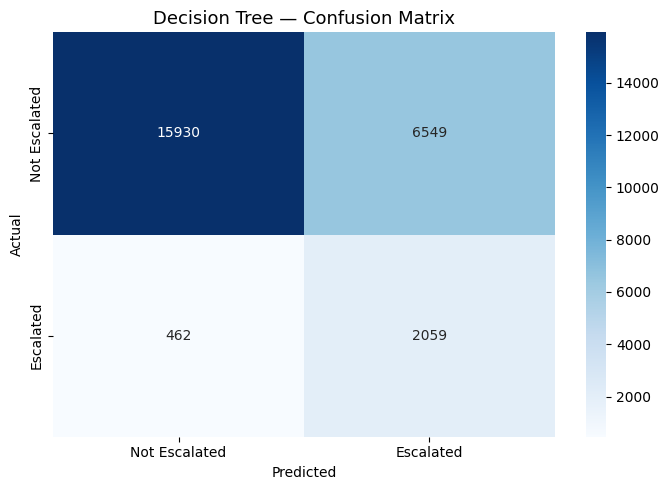

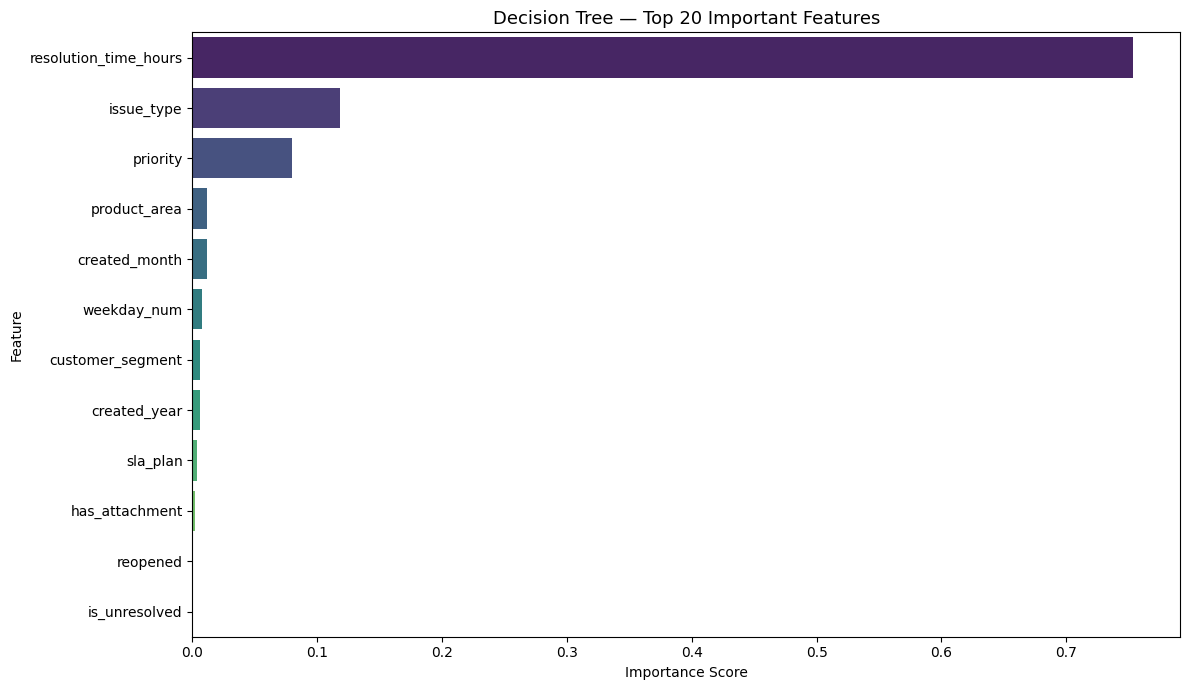

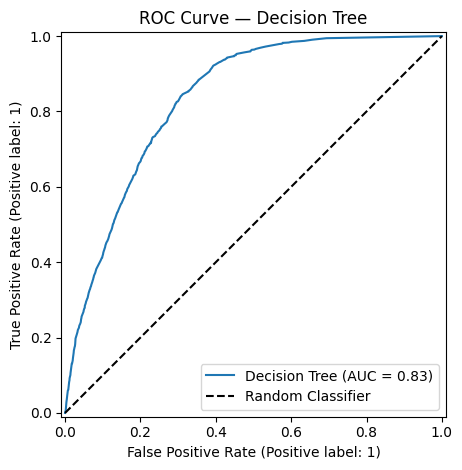

In [63]:
dt_params = {
    "max_depth"        : 10,
    "min_samples_leaf" : 50,
    'class_weight'     :'balanced',
    "random_state"     : 42
}

with mlflow.start_run(run_name="Decision_Tree"):

    dt_model = DecisionTreeClassifier(**dt_params)
    dt_model.fit(X_train, y_train)

    dt_metrics, dt_pred, dt_prob = evaluate_model(
        dt_model, X_test, y_test,
        model_name="Decision Tree"
    )

    mlflow.log_params(dt_params)
    mlflow.log_metrics(dt_metrics)
    mlflow.sklearn.log_model(dt_model, "decision_tree")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, dt_pred, "Decision Tree")
plot_feature_importance(dt_model, X_train.columns.tolist(), "Decision Tree")
plot_roc_curve(y_test, dt_prob, "Decision Tree")

2026/06/24 17:38:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 17:38:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Random Forest — Evaluation Results
  Accuracy  : 0.726
  F1 Score  : 0.3684
  Precision : 0.24
  Recall    : 0.7925
  ROC AUC   : 0.8293
               precision    recall  f1-score   support

Not Escalated       0.97      0.72      0.83     22479
    Escalated       0.24      0.79      0.37      2521

     accuracy                           0.73     25000
    macro avg       0.60      0.76      0.60     25000
 weighted avg       0.90      0.73      0.78     25000

MLflow run logged ✅


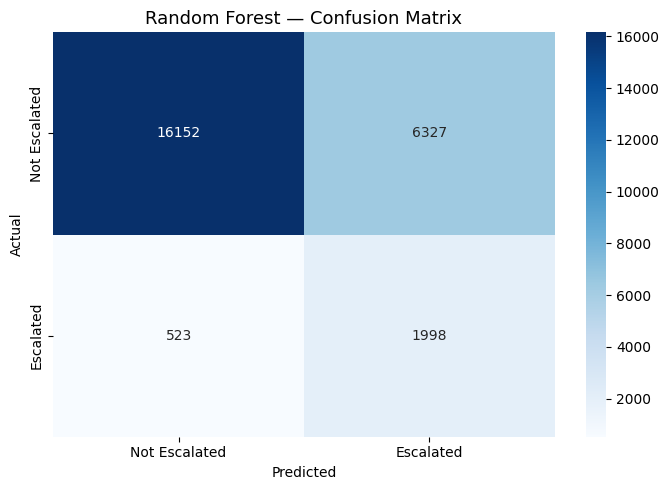

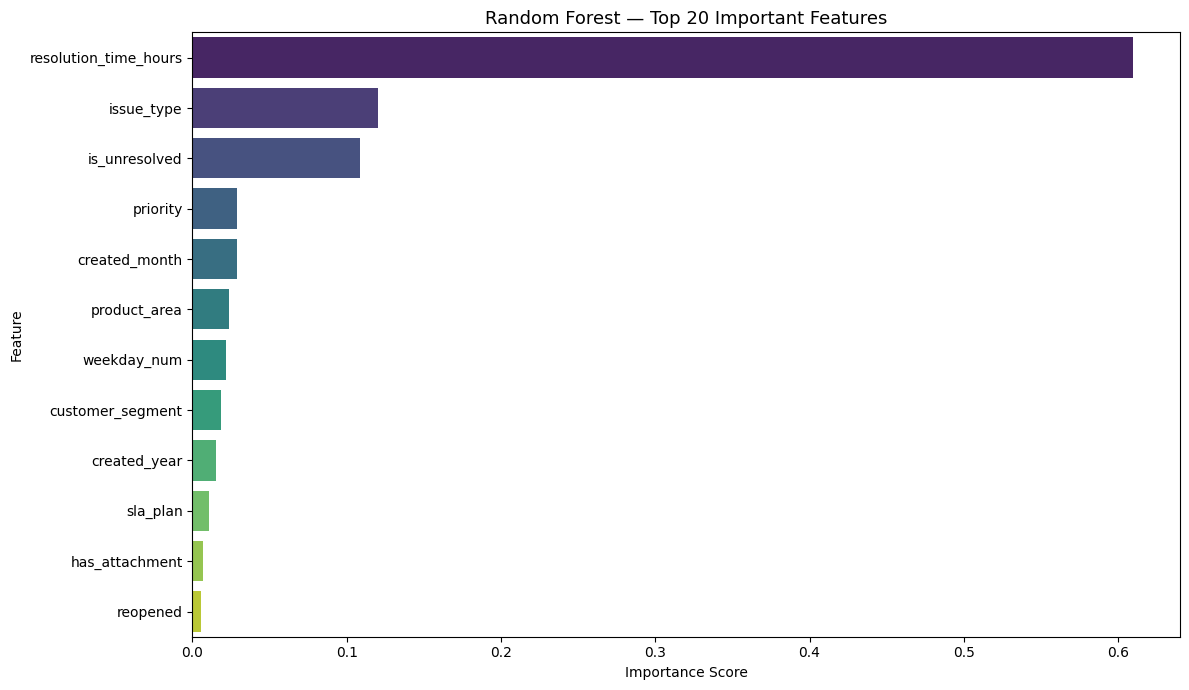

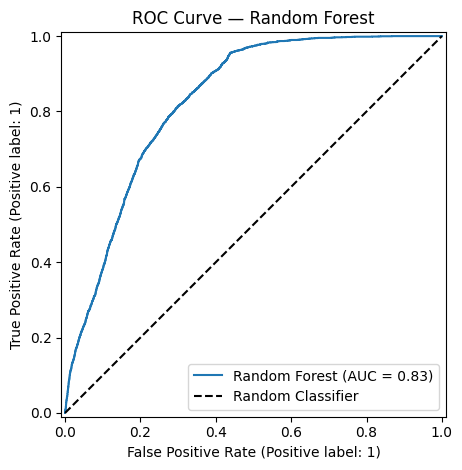

In [64]:
rf_params = {
    "n_estimators" : 200,
    "max_depth"    : 10,
    "n_jobs"       : -1,
    'class_weight'     :'balanced',
    "random_state" : 42
}

with mlflow.start_run(run_name="Random_Forest"):

    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train, y_train)

    rf_metrics, rf_pred, rf_prob = evaluate_model(
        rf_model, X_test, y_test,
        model_name="Random Forest"
    )

    mlflow.log_params(rf_params)
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_model, "random_forest")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, rf_pred, "Random Forest")
plot_feature_importance(rf_model, X_train.columns.tolist(), "Random Forest")
plot_roc_curve(y_test, rf_prob, "Random Forest")

2026/06/24 17:38:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Baseline — Evaluation Results
  Accuracy  : 0.7184
  F1 Score  : 0.3734
  Precision : 0.2407
  Recall    : 0.8318
  ROC AUC   : 0.8395
               precision    recall  f1-score   support

Not Escalated       0.97      0.71      0.82     22479
    Escalated       0.24      0.83      0.37      2521

     accuracy                           0.72     25000
    macro avg       0.61      0.77      0.60     25000
 weighted avg       0.90      0.72      0.77     25000

MLflow run logged ✅


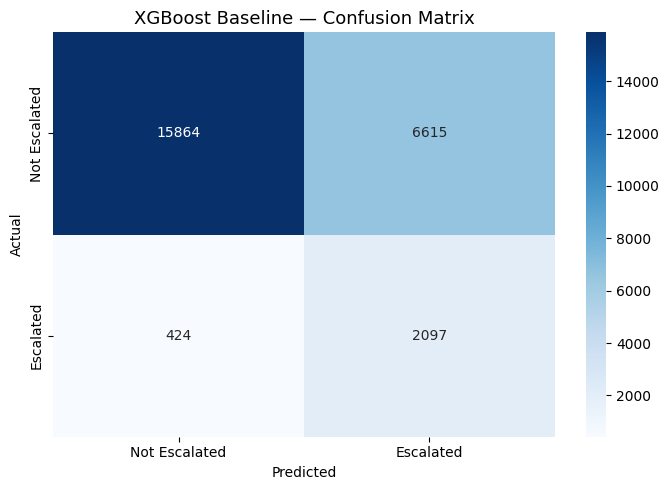

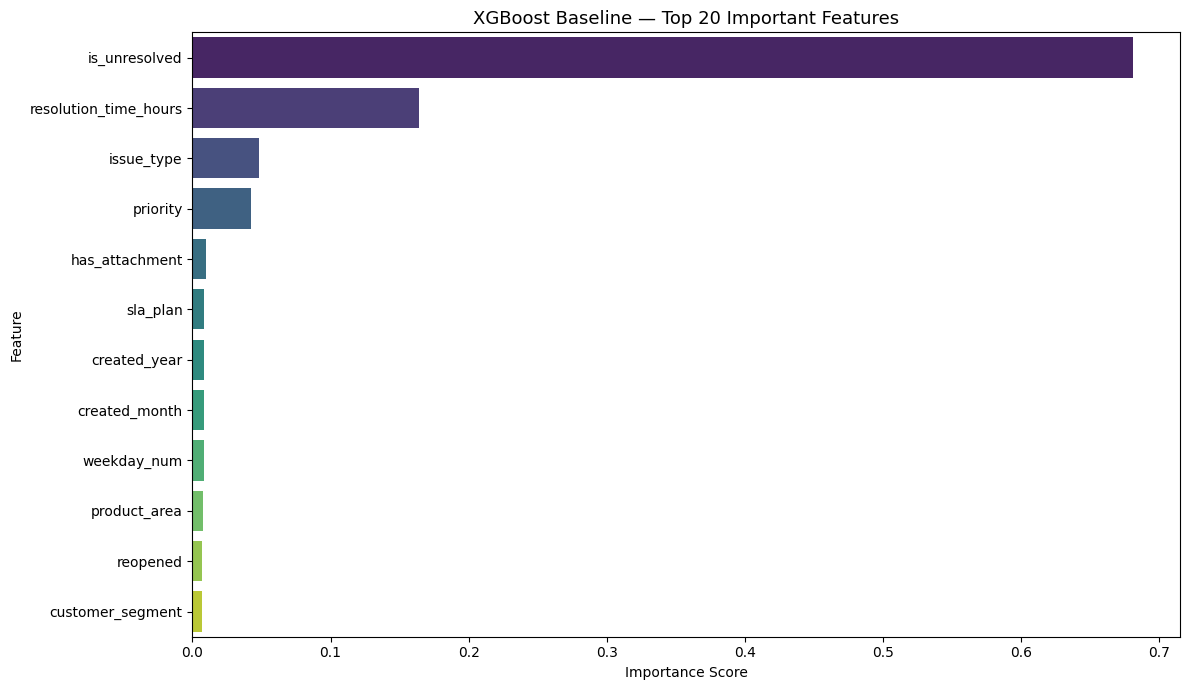

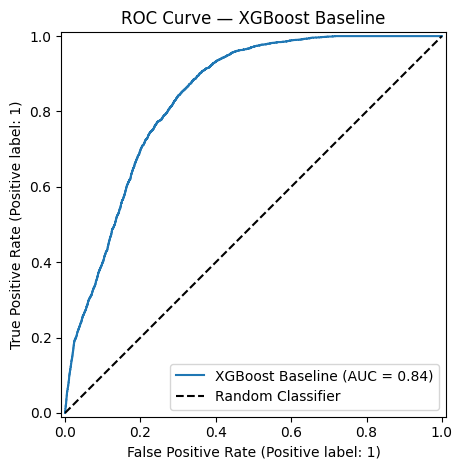

In [65]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_baseline_params = {
    "n_estimators"      : 100,
    "max_depth"         : 6,
    "learning_rate"     : 0.1,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    'scale_pos_weight': scale,
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Baseline"):

    xgb_baseline = XGBClassifier(**xgb_baseline_params)
    xgb_baseline.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_base_metrics, xgb_base_pred, xgb_base_prob = evaluate_model(
        xgb_baseline, X_test, y_test,
        model_name="XGBoost Baseline"
    )

    mlflow.log_params(xgb_baseline_params)
    mlflow.log_metrics(xgb_base_metrics)
    mlflow.xgboost.log_model(xgb_baseline, "xgboost_baseline")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_base_pred, "XGBoost Baseline")
plot_feature_importance(xgb_baseline, X_train.columns.tolist(), "XGBoost Baseline")
plot_roc_curve(y_test, xgb_base_prob, "XGBoost Baseline")

2026/06/24 17:39:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Tuned — Evaluation Results
  Accuracy  : 0.7135
  F1 Score  : 0.3722
  Precision : 0.2389
  Recall    : 0.8421
  ROC AUC   : 0.8411
               precision    recall  f1-score   support

Not Escalated       0.98      0.70      0.81     22479
    Escalated       0.24      0.84      0.37      2521

     accuracy                           0.71     25000
    macro avg       0.61      0.77      0.59     25000
 weighted avg       0.90      0.71      0.77     25000

MLflow run logged ✅


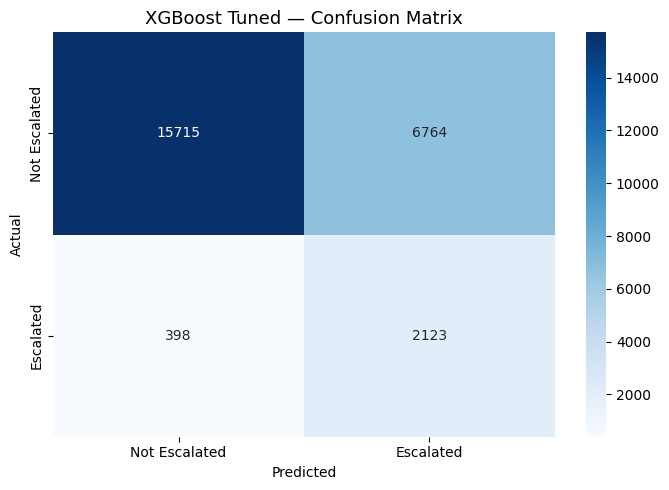

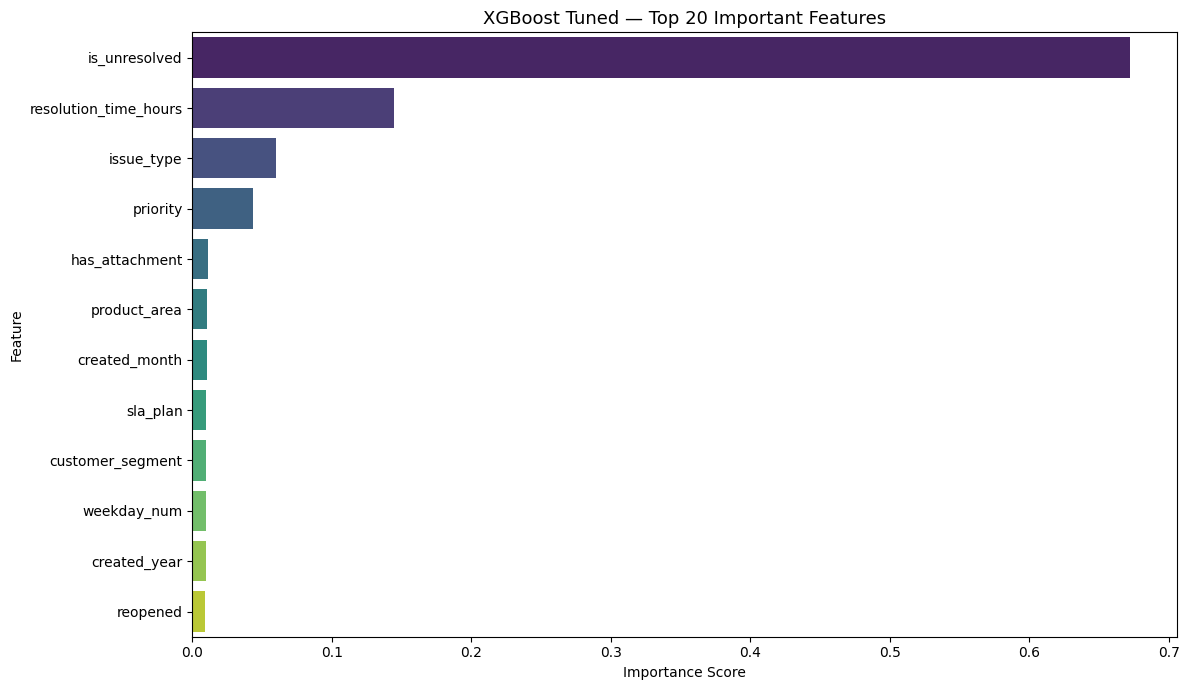

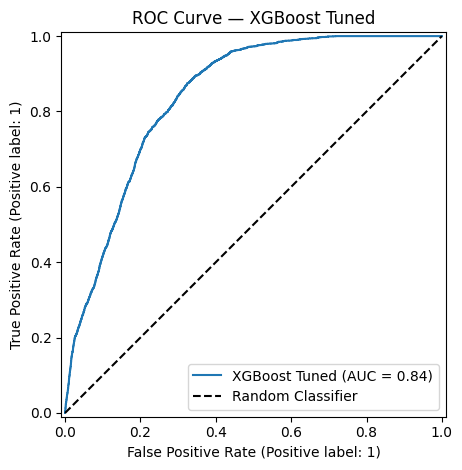

In [66]:
xgb_tuned_params = {
    "n_estimators"      : 300,
    "max_depth"         : 5,
    "learning_rate"     : 0.05,
    "min_child_weight"  : 3,
    "subsample"         : 0.8,
    "colsample_bytree"  : 0.8,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    'scale_pos_weight': scale,
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Tuned"):

    xgb_tuned = XGBClassifier(**xgb_tuned_params)
    xgb_tuned.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
        xgb_tuned, X_test, y_test,
        model_name="XGBoost Tuned"
    )

    mlflow.log_params(xgb_tuned_params)
    mlflow.log_metrics(xgb_tuned_metrics)
    mlflow.xgboost.log_model(xgb_tuned, "xgboost_tuned")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_tuned_pred, "XGBoost Tuned")
plot_feature_importance(xgb_tuned, X_train.columns.tolist(), "XGBoost Tuned")
plot_roc_curve(y_test, xgb_tuned_prob, "XGBoost Tuned")

2026/06/24 17:39:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/24 17:39:08 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LightGBM — Evaluation Results
  Accuracy  : 0.7141
  F1 Score  : 0.3727
  Precision : 0.2393
  Recall    : 0.8421
  ROC AUC   : 0.8407
               precision    recall  f1-score   support

Not Escalated       0.98      0.70      0.81     22479
    Escalated       0.24      0.84      0.37      2521

     accuracy                           0.71     25000
    macro avg       0.61      0.77      0.59     25000
 weighted avg       0.90      0.71      0.77     25000

MLflow run logged ✅


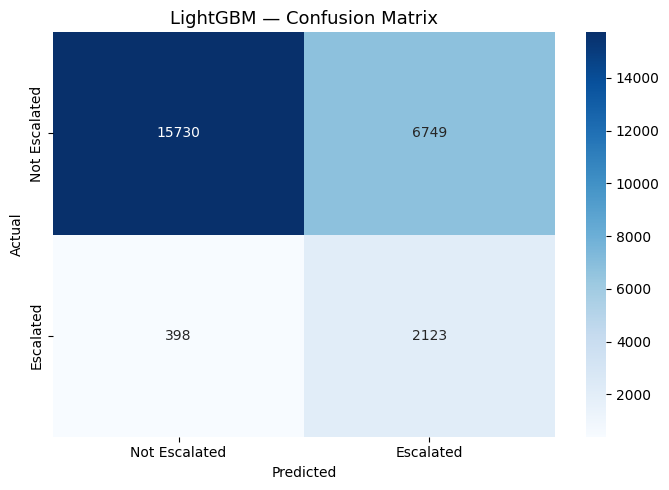

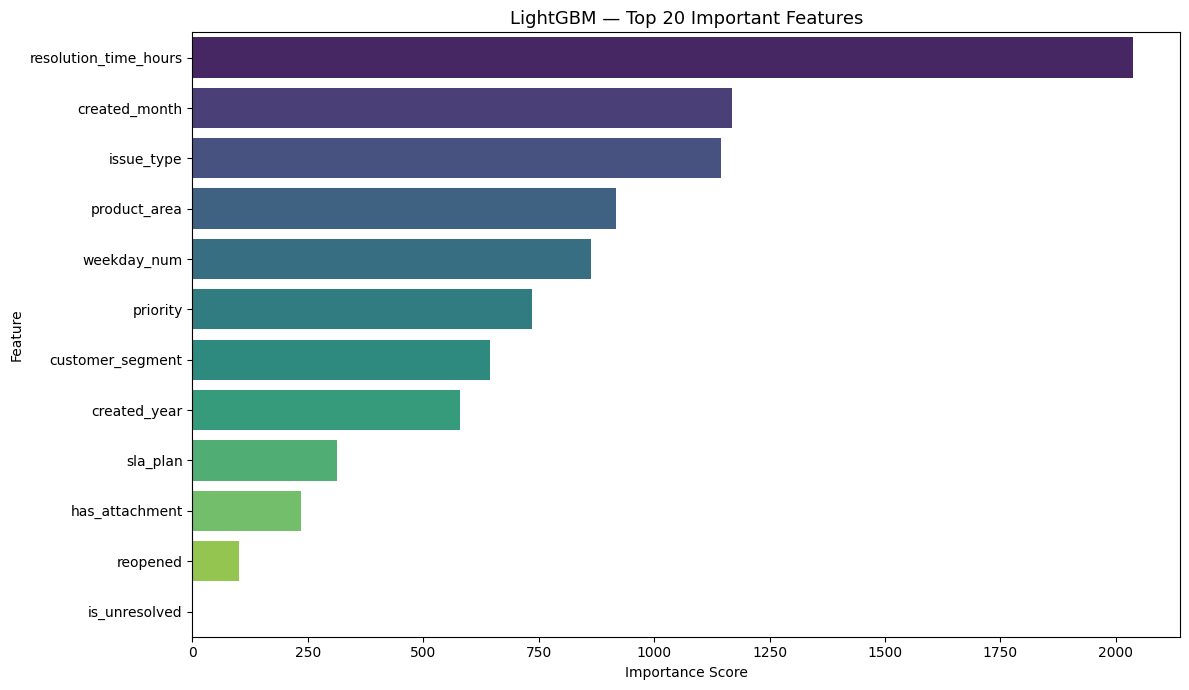

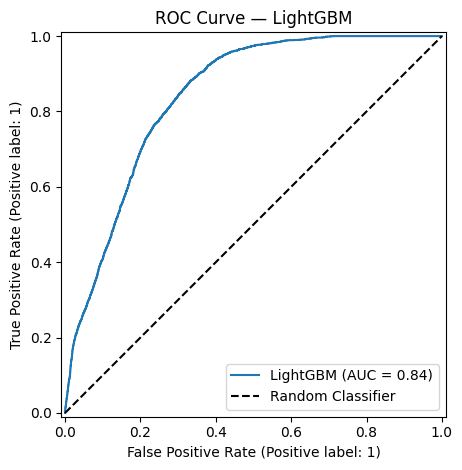

In [67]:
lgbm_params = {
    "n_estimators"  : 300,
    "max_depth"     : 5,
    "learning_rate" : 0.05,
    "subsample"     : 0.8,
    "random_state"  : 42,
    'class_weight'     :'balanced',
    "n_jobs"        : -1,
    "verbose"       : -1
}

with mlflow.start_run(run_name="LightGBM"):

    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)]
    )

    lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(
        lgbm_model, X_test, y_test,
        model_name="LightGBM"
    )

    mlflow.log_params(lgbm_params)
    mlflow.log_metrics(lgbm_metrics)
    mlflow.lightgbm.log_model(lgbm_model, "lightgbm")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, lgbm_pred, "LightGBM")
plot_feature_importance(lgbm_model, X_train.columns.tolist(), "LightGBM")
plot_roc_curve(y_test, lgbm_prob, "LightGBM")

In [73]:
results = pd.DataFrame({
    'Model'    : [
        'Decision Tree',
        'Random Forest',
        'XGBoost Baseline',
        'XGBoost Tuned',
        'LightGBM'
    ],
    'Accuracy' : [
        dt_metrics['accuracy'],
        rf_metrics['accuracy'],
        xgb_base_metrics['accuracy'],
        xgb_tuned_metrics['accuracy'],
        lgbm_metrics['accuracy']
    ],
    'F1 Score' : [
        dt_metrics['f1_score'],
        rf_metrics['f1_score'],
        xgb_base_metrics['f1_score'],
        xgb_tuned_metrics['f1_score'],
        lgbm_metrics['f1_score']
    ],
    'Precision': [
        dt_metrics['precision'],
        rf_metrics['precision'],
        xgb_base_metrics['precision'],
        xgb_tuned_metrics['precision'],
        lgbm_metrics['precision']
    ],
    'Recall'   : [
        dt_metrics['recall'],
        rf_metrics['recall'],
        xgb_base_metrics['recall'],
        xgb_tuned_metrics['recall'],
        lgbm_metrics['recall']
    ],
    'ROC AUC'  : [
        dt_metrics['roc_auc'],
        rf_metrics['roc_auc'],
        xgb_base_metrics['roc_auc'],
        xgb_tuned_metrics['roc_auc'],
        lgbm_metrics['roc_auc']
    ]
})

#Highlight best value in each column
results = results.sort_values('Recall', ascending=False)
results = results.reset_index(drop=True)

print("\n" + "="*75)
print("  FINAL MODEL COMPARISON")
print("="*75)
print(results.to_string(index=False))
print("="*75)
print(f"\n🏆 Best Model by Recall: {results.iloc[0]['Model']}")


  FINAL MODEL COMPARISON
           Model  Accuracy  F1 Score  Precision  Recall  ROC AUC
   XGBoost Tuned    0.7135    0.3722     0.2389  0.8421   0.8411
        LightGBM    0.7141    0.3727     0.2393  0.8421   0.8407
XGBoost Baseline    0.7184    0.3734     0.2407  0.8318   0.8395
   Decision Tree    0.7196    0.3700     0.2392  0.8167   0.8341
   Random Forest    0.7260    0.3684     0.2400  0.7925   0.8293

🏆 Best Model by Recall: XGBoost Tuned


In [69]:
# Check correlation of every feature with target
correlations = X_train.copy()
correlations['escalated'] = y_train.values

corr_with_target = correlations.corr()['escalated'].drop('escalated')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

print("Top 20 features correlated with escalated:")
print(corr_with_target.head(20))

Top 20 features correlated with escalated:
is_unresolved            0.187496
resolution_time_hours    0.120269
created_month            0.009341
weekday_num              0.008469
created_year             0.004928
priority                 0.004566
issue_type               0.003581
product_area             0.002787
sla_plan                 0.002149
has_attachment           0.001765
customer_segment         0.000962
reopened                 0.000123
Name: escalated, dtype: float64


In [75]:
#Map model name to actual trained object
model_map = {
    'Decision Tree'    : dt_model,
    'Random Forest'    : rf_model,
    'XGBoost Baseline' : xgb_baseline,
    'XGBoost Tuned'    : xgb_tuned,
    'LightGBM'         : lgbm_model
}

best_model_name = results.iloc[0]['Model']
best_model      = model_map[best_model_name]

In [76]:
joblib.dump(best_model, 'models/saved_models/best_tabular_model.pkl')
print("Best model saved ✅")

Best model saved ✅
